In [1]:

#%% Run to have everything 

import torch
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../tgv_pycuda-master"))
sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))




from Algo_setuptorch import Params

from data.dataset import build_train_test_data


from algorithm.unrolled_model import UnrolledFBS
from algorithm.unrolled_model_Unet import UnrolledFBS_Unet
from training.train import train
from NN_V9.plots import *
from NN_V9.run import *



from pghd_denoising import pdhg






device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

params = Params()

TRAIN_SEEDS = list(range(50))  
TEST_SEEDS = list(range(50,60))


size = params.size
SHAPES = [
    (1, 1, size, size),
    (1, 2, size, size),
    (1, 2, size, size),
    (1, 3, size, size),
]
N_CH = sum(s[1] for s in SHAPES)
N_CH_primal = sum(s[1] for s in SHAPES[:2])
print("ok")

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)


initial_state, clean, functions = test_data[0]


u_clean = clean.to(device)

x_clean = [
    u_clean,
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 3, size, size), device=device),
]

print(functions["kkt_residual_norm"](x_clean))

/home/beille/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Device: cpu
ok
0.16517450704
0.0
0.115852114166
0.0
0.179408494132
0.0
0.0989274306804
0.0
0.104631883019
0.0
0.185678342443
0.0
0.0656345245735
0.0
0.143496655203
0.0
0.158385455465
0.0
0.082550589528
0.0
0.0884490581673
0.0
0.142096212653
0.0
0.197083060827
0.0
0.198637057459
0.0
0.0990259933798
0.0
0.0577168940816
0.0
0.0853074307147
0.0
0.135614645535
0.0
0.0748336416358
0.0
0.168118854905
0.0
0.105597291068
0.0
0.148347748821
0.0
0.0880504250274
0.0
0.0775832423499
0.0
0.139025887413
0.0
0.168214032528
0.0
0.181264284257
0.0
0.136774888331
0.0
0.108988869177
0.0
0.116760074387
0.0
0.0935774214916
0.0
0.0653487075864
0.0
0.0662768185691
0.0
0.0706161641695
0.0
0.189755735219
0.0
0.114278009234
0.0
0.181331254165
0.0
0.0871663783401
0.0
0.0959998492853
0.0
0.142240863374
0.0
0.119461209232
0.0
0.153233564406
0.0
0.192794346205
0.0
0.152417004337
0.0
0.182925599636
0.0
0.120457962639
0.0
0.142422569727
0.0
0.0556049019375
0.0
0.18681532386
0.0
0.0684196458916
0.0
0.135294309713
0.0
0

In [6]:

model_Unet = UnrolledFBS_Unet(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=10,
    alpha=0.99,
).to(device).float()

model_Unet.load_state_dict(torch.load("model_final_10_AxCx_Unet.pt", map_location="cpu"))

model_Unet.eval()
 
 
model_CNN = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=10,
    alpha=0.99,
).to(device).float()

model_CNN.load_state_dict(torch.load("model_final_10_AxCx.pt", map_location="cpu"))

model_CNN.eval()

UnrolledFBS(
  (dev_net): DeviationNet(
    (input_embed): Sequential(
      (0): Conv2d(21, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (body): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (norm2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  

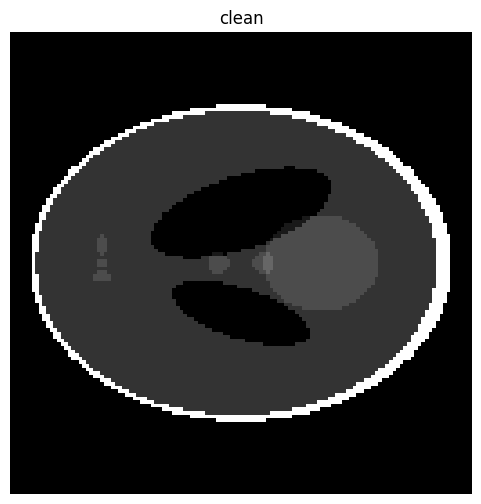

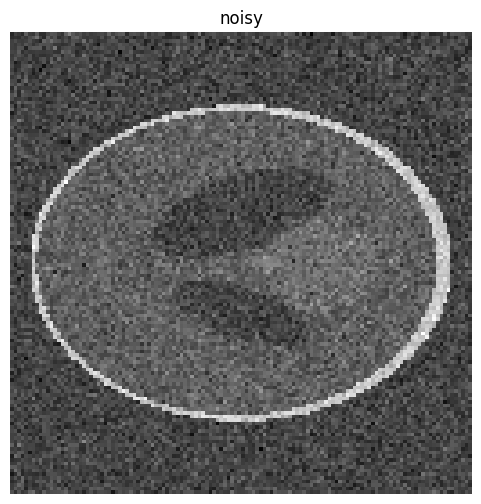

iter:0
17.034425735473633
iter:1
20.921276092529297
iter:2
23.69967269897461
iter:3
24.32162857055664
iter:4
23.521913528442383
iter:5
22.05242156982422
iter:6
20.33444595336914
iter:7
18.694416046142578
iter:8
17.2774715423584
iter:9
16.127044677734375
iter:10
15.22008228302002
iter:11
14.493021965026855
iter:12
13.872207641601562
iter:13
13.30634593963623
iter:14
12.772676467895508
iter:15
12.267955780029297
iter:16
11.793819427490234
iter:17
11.353774070739746
iter:18
10.952921867370605
iter:19
10.593584060668945
iter:20
10.272591590881348
iter:21
9.989104270935059
iter:22
9.735315322875977
iter:23
9.500570297241211
iter:24
9.277968406677246
iter:25
9.063458442687988
iter:26
8.85155963897705
iter:27
8.639727592468262
iter:28
8.428628921508789
iter:29
8.219575881958008
iter:30
8.013628005981445
iter:31
7.810660362243652
iter:32
7.612513542175293
iter:33
7.418846607208252
iter:34
7.230463981628418
iter:35
7.0458526611328125
iter:36
6.865094184875488
iter:37
6.688132286071777
iter:38
6

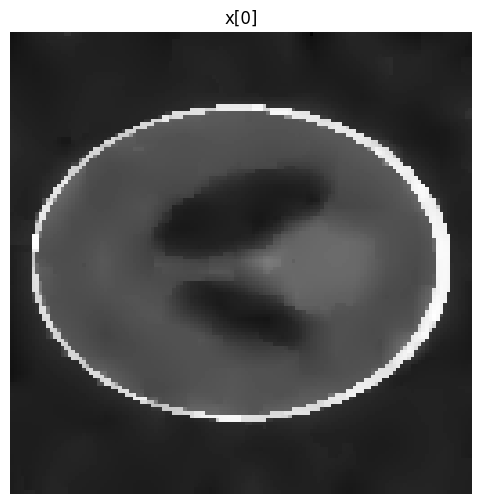

In [2]:

import matplotlib.pyplot as plt
img_clean=clean.detach().cpu().squeeze()
img_noisy=initial_state.detach().cpu().squeeze()

plt.figure(figsize=(6,6))
plt.imshow(img_clean, cmap='gray')
plt.axis('off')
plt.title("clean")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(img_noisy, cmap='gray')
plt.axis('off')
plt.title("noisy")
plt.show()
F_vals_0, res_0,x= run_zero(initial_state,functions, params, SHAPES, 500, device)
img = x[0].detach().cpu().squeeze()
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("x[0]")
plt.show()

In [7]:
F_vals_0, res_0,x= run_zero(initial_state,functions, params, SHAPES, 500, device)
F_vals_Unet,res_Unet= run_learned(model_Unet,initial_state,clean,functions,T_test=500)
F_vals_CNN,res_CNN= run_learned(model_CNN,initial_state,clean,functions,T_test=500)

#import matplotlib.pyplot as plt

""" img = history["x"][-1][0]

# convertir proprement
img_np = img.detach().cpu().squeeze().numpy()

plt.imsave("final_image.png", img_np, cmap="gray") """

iter:0
17.034425735473633
iter:1
20.921276092529297
iter:2
23.69967269897461
iter:3
24.32162857055664
iter:4
23.521913528442383
iter:5
22.05242156982422
iter:6
20.33444595336914
iter:7
18.694416046142578
iter:8
17.2774715423584
iter:9
16.127044677734375
iter:10
15.22008228302002
iter:11
14.493021965026855
iter:12
13.872207641601562
iter:13
13.30634593963623
iter:14
12.772676467895508
iter:15
12.267955780029297
iter:16
11.793819427490234
iter:17
11.353774070739746
iter:18
10.952921867370605
iter:19
10.593584060668945
iter:20
10.272591590881348
iter:21
9.989104270935059
iter:22
9.735315322875977
iter:23
9.500570297241211
iter:24
9.277968406677246
iter:25
9.063458442687988
iter:26
8.85155963897705
iter:27
8.639727592468262
iter:28
8.428628921508789
iter:29
8.219575881958008
iter:30
8.013628005981445
iter:31
7.810660362243652
iter:32
7.612513542175293
iter:33
7.418846607208252
iter:34
7.230463981628418
iter:35
7.0458526611328125
iter:36
6.865094184875488
iter:37
6.688132286071777
iter:38
6

' img = history["x"][-1][0]\n\n# convertir proprement\nimg_np = img.detach().cpu().squeeze().numpy()\n\nplt.imsave("final_image.png", img_np, cmap="gray") '

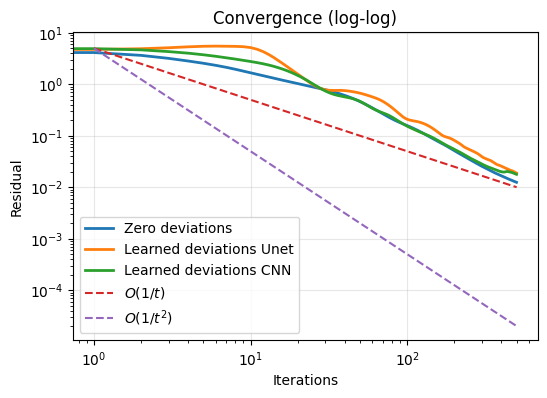

In [8]:

# Convertir en numpy si besoin
res_0 = np.array(res_0)
res_Unet = np.array(res_Unet)
res_CNN = np.array(res_CNN)
# Axe des itérations 
iters = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6,4))

# Courbes principales

plt.loglog(res_0, label='Zero deviations', linewidth=2)
plt.loglog(res_Unet, label='Learned deviations Unet', linewidth=2)
plt.loglog(res_CNN, label='Learned deviations CNN', linewidth=2)
# Références théoriques
plt.semilogy(iters, res_0[0]/iters, '--', label=r'$O(1/t)$')
plt.semilogy(iters, res_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

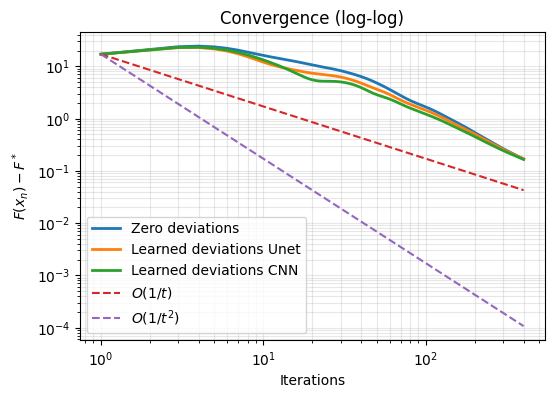

In [10]:
# convertir proprement
F_vals_0 = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_0
])

F_vals_Unet = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_Unet
]) 
F_vals_CNN = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_CNN
]) 

# approx de F*

AxCxmin=F_vals_0.min()
# gaps
gap_0 = F_vals_0
gap_Unet   = F_vals_Unet
gap_CNN=F_vals_CNN
# éviter log(0)
gap_0 = np.maximum(gap_0, 1e-16)
gap_Unet   = np.maximum(gap_Unet,   1e-16)
gap_CNN   = np.maximum(gap_CNN,   1e-16)
gap_0 = gap_0[:400]
gap_Unet   =gap_Unet[:400]
gap_CNN   =gap_CNN[:400]

iters = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6,4))

plt.loglog(iters, gap_0, label='Zero deviations', linewidth=2)
plt.loglog(iters, gap_Unet,   label='Learned deviations Unet', linewidth=2)
plt.loglog(iters, gap_CNN,   label='Learned deviations CNN', linewidth=2)
# références
plt.loglog(iters, gap_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, gap_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel(r'$F(x_n) - F^*$')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

In [12]:

data = initial_state.detach().cpu().squeeze().numpy()

x, F_vals_pdhg = pdhg(data)

F_vals_learned,res_learned = run_learned(model_CNN,initial_state,clean,functions,T_test=500)



iter = 0
Iter 1: F(x) = 124.248821
iter = 1
Iter 2: F(x) = 122.384656
iter = 2
Iter 3: F(x) = 119.389363
iter = 3
Iter 4: F(x) = 115.516011
iter = 4
Iter 5: F(x) = 111.067387
iter = 5
Iter 6: F(x) = 106.331325
iter = 6
Iter 7: F(x) = 101.529162
iter = 7
Iter 8: F(x) = 96.701271
iter = 8
Iter 9: F(x) = 91.864746
iter = 9
Iter 10: F(x) = 87.087710
iter = 10
Iter 11: F(x) = 82.458058
iter = 11
Iter 12: F(x) = 78.077427
iter = 12
Iter 13: F(x) = 74.033308
iter = 13
Iter 14: F(x) = 70.363521
iter = 14
Iter 15: F(x) = 67.093891
iter = 15
Iter 16: F(x) = 64.265416
iter = 16
Iter 17: F(x) = 61.917090
iter = 17
Iter 18: F(x) = 60.049839
iter = 18
Iter 19: F(x) = 58.649089
iter = 19
Iter 20: F(x) = 57.697966
iter = 20
Iter 21: F(x) = 57.167886
iter = 21
Iter 22: F(x) = 57.009633
iter = 22
Iter 23: F(x) = 57.160522
iter = 23
Iter 24: F(x) = 57.561235
iter = 24
Iter 25: F(x) = 58.158591
iter = 25
Iter 26: F(x) = 58.894114
iter = 26
Iter 27: F(x) = 59.714835
iter = 27
Iter 28: F(x) = 60.573107
iter

[ 17.03442574  20.55642319  22.93066025  23.20340919  22.09490204
  20.36843681  18.42868423  16.52539062  14.78064156  13.24327374
  11.91203403  10.7524271    9.72646427   8.80925083   7.99044752
   7.27235174   6.6607151    6.16279602   5.78104877   5.50955915
   5.33367777   5.23388815   5.18614769   5.16827011   5.16327047
   5.15900326   5.14640617   5.12069082   5.07963753   5.02282238
   4.9516902    4.86738443   4.77136278   4.66580963   4.55207157
   4.43080997   4.30414391   4.17320347   4.03972578   3.90515852
   3.77128911   3.64030957   3.51364994   3.39306021   3.28034973
   3.17635131   3.08146548   2.99579382   2.91898179   2.85040808
   2.78874421   2.73260713   2.68062329   2.63146353   2.58423543
   2.53802299   2.4922297    2.44615841   2.3998301    2.35324073
   2.30624628   2.25931215   2.21258044   2.16608763   2.1198082
   2.07427144   2.02967      1.98636484   1.94411957   1.90332568
   1.86405599   1.82651722   1.79066432   1.75662744   1.72427297
   1.693556

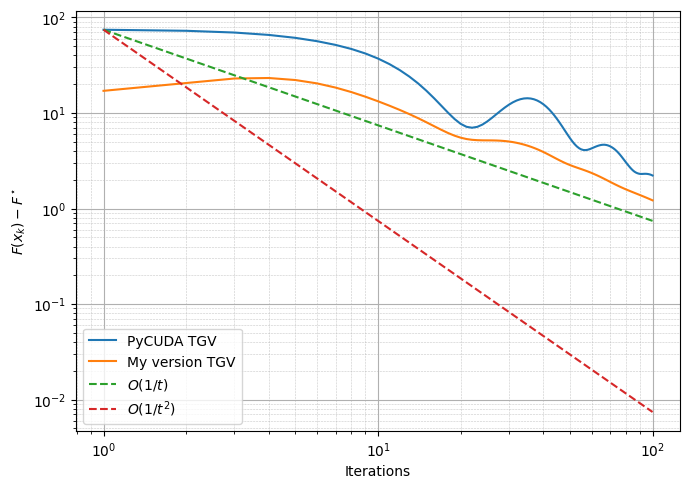

In [13]:
gaps = np.array(F_vals_pdhg)
gaps_learned = np.array(F_vals_learned)
print(gaps_learned)


# --------------------------------------------------
# center wrt minimum value
# --------------------------------------------------

fmin = gaps.min(), 
AxCxmin=gaps_learned.min()

gaps = gaps -fmin
gaps_learned = gaps_learned 



# --------------------------------------------------
gaps = gaps[:100]
gaps_learned = gaps_learned[:100]
N = min(len(gaps), len(gaps_learned))
t = np.arange(1, N + 1)

plt.figure(figsize=(7, 5))

plt.loglog(t, gaps[:N], label="PyCUDA TGV")
plt.loglog(t, gaps_learned[:N], label="My version TGV")

# --------------------------------------------------
# reference rates normalized to first value
# --------------------------------------------------

ref1 = gaps[0] / t
ref2 = gaps[0] / (t**2)

plt.loglog(t, ref1, '--', label=r'$O(1/t)$')
plt.loglog(t, ref2, '--', label=r'$O(1/t^2)$')

# --------------------------------------------------

plt.xlabel("Iterations")
plt.ylabel(r"$F(x_k)-F^\star$")
plt.legend()

plt.minorticks_on()

plt.grid(which='major', linestyle='-', linewidth=0.8)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.7)

plt.tight_layout()

plt.savefig("energy.pdf")
plt.show()

iter = 0
Iter 1: F(x) = 101.220671
iter = 1
Iter 2: F(x) = 99.044208
iter = 2
Iter 3: F(x) = 95.864872
iter = 3
Iter 4: F(x) = 91.919798
iter = 4
Iter 5: F(x) = 87.480511
iter = 5
Iter 6: F(x) = 82.793667
iter = 6
Iter 7: F(x) = 78.062028
iter = 7
Iter 8: F(x) = 73.312884
iter = 8
Iter 9: F(x) = 68.549234
iter = 9
Iter 10: F(x) = 63.846783
iter = 10
Iter 11: F(x) = 59.269381
iter = 11
Iter 12: F(x) = 54.928965
iter = 12
Iter 13: F(x) = 50.939975
iter = 13
Iter 14: F(x) = 47.331245
iter = 14
Iter 15: F(x) = 44.108632
iter = 15
Iter 16: F(x) = 41.309470
iter = 16
Iter 17: F(x) = 38.985589
iter = 17
Iter 18: F(x) = 37.150129
iter = 18
Iter 19: F(x) = 35.780336
iter = 19
Iter 20: F(x) = 34.856309
iter = 20
Iter 21: F(x) = 34.350906
iter = 21
Iter 22: F(x) = 34.209445
iter = 22
Iter 23: F(x) = 34.366292
iter = 23
Iter 24: F(x) = 34.765248
iter = 24
Iter 25: F(x) = 35.360804
iter = 25
Iter 26: F(x) = 36.098065
iter = 26
Iter 27: F(x) = 36.924062
iter = 27
Iter 28: F(x) = 37.794386
iter = 28


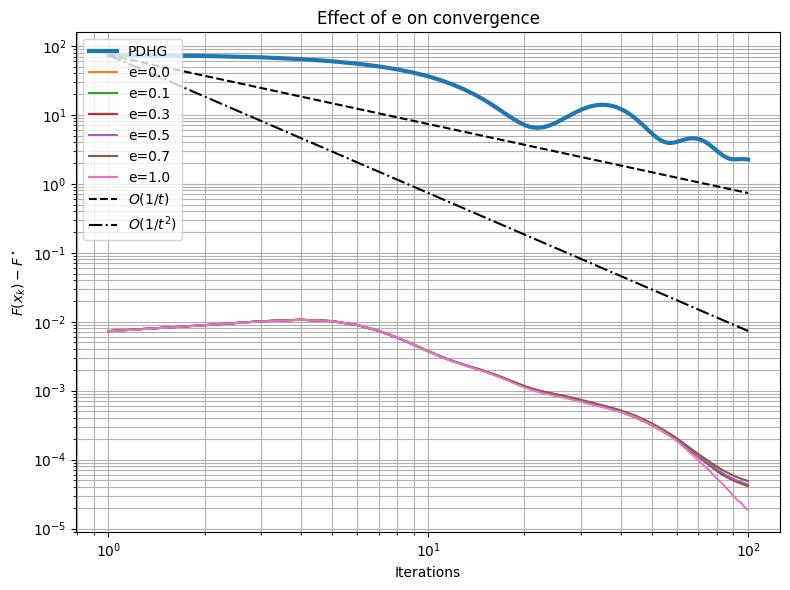

In [7]:
results = {}

es = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]

# ==========================================================
# PDHG reference
# ==========================================================

data = initial_state.detach().cpu().squeeze().numpy()

x_pdhg, F_vals_pdhg = pdhg(data)

gaps_pdhg = np.array(F_vals_pdhg)

fstar_pdhg = gaps_pdhg.min()

gaps_pdhg = np.maximum(
    gaps_pdhg - fstar_pdhg,
    1e-12
)

results["PDHG"] = {
    "gaps": gaps_pdhg,
}

# ==========================================================
# Run YOUR algorithm for different e
# ==========================================================

for e in es:

    print(f"Running e = {e}")

    params = Params()

    # λ_n = λ0 (1+n)^e
    params.lam = lambda n, e=e: params.lam0 * (1 + n)**e

    F_vals, residuals, x = run_zero(
        initial_state,
        functions,
        params,
        SHAPES,
        500,
        device
    )

    gaps = np.array(F_vals)

    fstar = gaps.min()

    gaps = np.maximum(
        gaps - fstar,
        1e-12
    )

    results[e] = {
        "gaps": gaps,
        "residuals": np.array(residuals),
    }

# ==========================================================
# Plot energies
# ==========================================================

plt.figure(figsize=(8,6))

# ----------------------------------------------------------
# PDHG
# ----------------------------------------------------------

gaps = results["PDHG"]["gaps"][:100]

t = np.arange(1, len(gaps)+1)

plt.loglog(
    t,
    gaps,
    linewidth=3,
    label="PDHG"
)

# ----------------------------------------------------------
# Learned / Algorithm 1
# ----------------------------------------------------------

for e in es:

    gaps = results[e]["gaps"][:100]

    t = np.arange(1, len(gaps)+1)

    plt.loglog(
        t,
        gaps,
        label=f"e={e}"
    )

# ----------------------------------------------------------
# theoretical rates
# ----------------------------------------------------------

tref = np.arange(1, 101)

ref1 = gaps_pdhg[0] / tref
ref2 = gaps_pdhg[0] / (tref**2)

plt.loglog(
    tref,
    ref1,
    'k--',
    label=r"$O(1/t)$"
)

plt.loglog(
    tref,
    ref2,
    'k-.',
    label=r"$O(1/t^2)$"
)

# ----------------------------------------------------------

plt.xlabel("Iterations")

plt.ylabel(r"$F(x_k)-F^\star$")

plt.title("Effect of e on convergence")

plt.legend()

plt.grid(True, which="both")

plt.tight_layout()

plt.savefig("effect_of_e.pdf")

plt.show()

